In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.decomposition import PCA

In [3]:
from GTD_features import unscale
 
sns.set_theme(style="whitegrid")
 
df = pd.read_csv("D:\MLCOE PROBATION TASKS\TASK 3\Data\gtd_model_ready.csv")
num = df.select_dtypes(include=[np.number]).drop(columns=["eventid"])

In [4]:
USE_IMPUTATION_FLAGS = False
if not USE_IMPUTATION_FLAGS:
    flag_cols = [c for c in num.columns if c.endswith(("_was_missing", "_was_unknown"))]
    num = num.drop(columns=flag_cols)
print("Numeric features going into PCA:", num.shape)
print(list(num.columns))

Numeric features going into PCA: (181691, 34)
['iyear', 'imonth', 'iday', 'extended', 'latitude', 'longitude', 'specificity', 'crit1', 'crit2', 'crit3', 'multiple', 'success', 'suicide', 'guncertain1', 'individual', 'nperps', 'nperpcap', 'nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus', 'nwoundte', 'decade', 'casualties_total', 'is_multi_faceted', 'group_known', 'country_txt_freq', 'provstate_freq', 'city_freq', 'targsubtype1_txt_freq', 'natlty1_txt_freq', 'gname_freq', 'weapsubtype1_txt_freq']


In [5]:
pca = PCA(random_state=42)
pca.fit(num)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

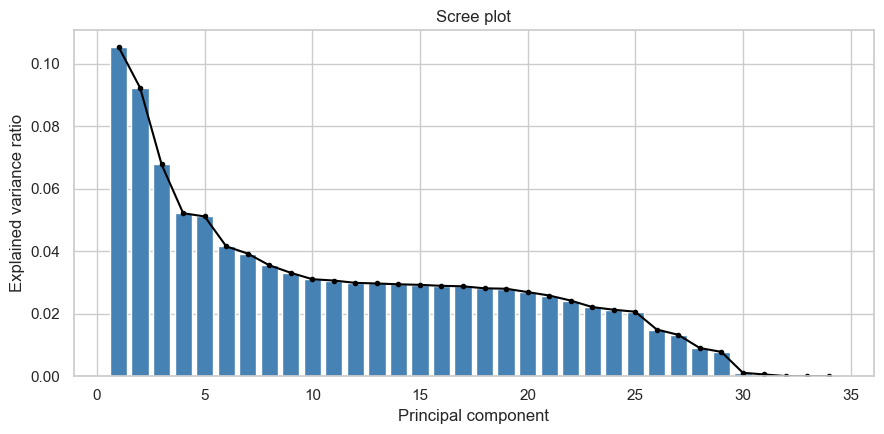

In [ ]:
plt.figure(figsize=(9, 4.5))
plt.bar(range(1, len(evr) + 1), evr, color="steelblue")
plt.plot(range(1, len(evr) + 1), evr, color="black", marker="o", ms=3)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot")
plt.tight_layout()
plt.show()

**Insight**:

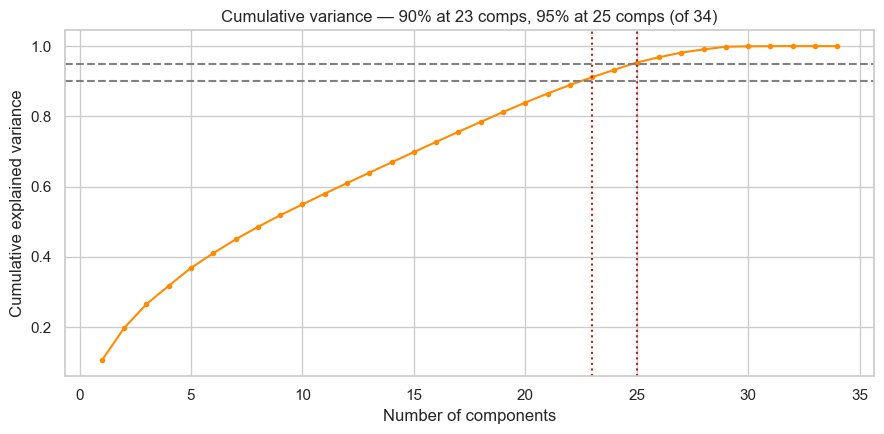

In [ ]:
n90 = int(np.argmax(cum >= 0.90) + 1)
n95 = int(np.argmax(cum >= 0.95) + 1)
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, len(cum) + 1), cum, marker="o", ms=3, color="darkorange")
plt.axhline(0.90, ls="--", color="gray")
plt.axhline(0.95, ls="--", color="gray")
plt.axvline(n90, ls=":", color="firebrick")
plt.axvline(n95, ls=":", color="firebrick")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title(f"Cumulative variance — 90% at {n90} comps, 95% at {n95} comps "
          f"(of {num.shape[1]})")
plt.tight_layout()
plt.show()

**Insight**:

In [8]:
print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")
print("First 5 components explain:", np.round(evr[:5] * 100, 1), "%")

Components for 90% variance: 23
Components for 95% variance: 25
First 5 components explain: [10.5  9.2  6.8  5.2  5.1] %


In [10]:
scaler = joblib.load("D:\MLCOE PROBATION TASKS\TASK 3\models\scaler.pkl")
nkill_raw = unscale(scaler, "nkill", df["nkill"])
unknown = unscale(scaler, "nkill_was_missing", df["nkill_was_missing"]) > 0.5

In [11]:
scores = pd.DataFrame(pca.transform(num)[:, :2], columns=["PC1", "PC2"])
scores["fatal"] = np.where(nkill_raw.values > 0.5, "Fatal", "Non-fatal")
scores = scores[~unknown.values]
samp = scores.sample(20000, random_state=42)

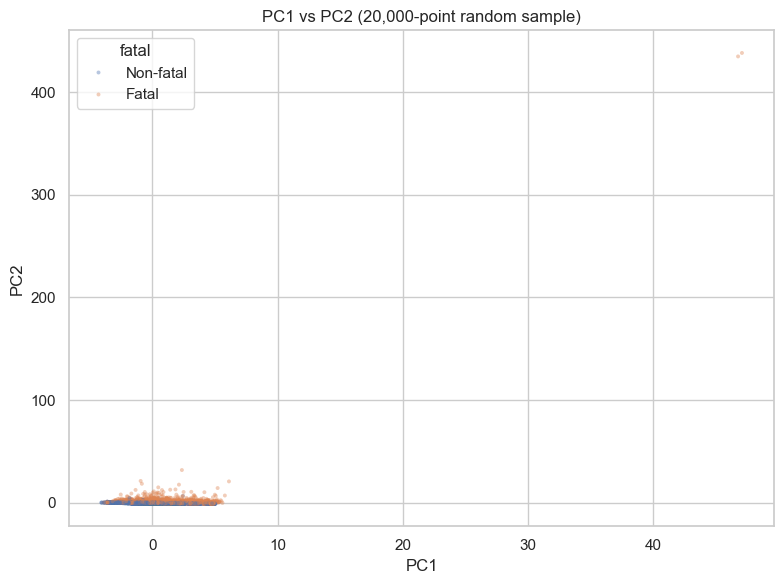

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=samp, x="PC1", y="PC2", hue="fatal", s=8, alpha=0.4, linewidth=0)
plt.title("PC1 vs PC2 (20,000-point random sample)")
plt.tight_layout()
plt.show()

**Insight**: